# Imports

In [ ]:
!pip install scikit-learn scikit-learn-extra pyclustering ucimlrepo

In [25]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as py
import itertools

from pyclustering.utils.metric import distance_metric, type_metric
from sklearn import datasets, metrics
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import DBSCAN, KMeans

from yellowbrick.cluster import KElbowVisualizer

from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Laod Dataset

In [11]:
# fetch dataset
users = fetch_ucirepo(id=257)
X = users.data.features
y = users.data.targets

print(users.metadata)
print(users.variables)

{'uci_id': 257, 'name': 'User Knowledge Modeling', 'repository_url': 'https://archive.ics.uci.edu/dataset/257/user+knowledge+modeling', 'data_url': 'https://archive.ics.uci.edu/static/public/257/data.csv', 'abstract': "It is the real dataset about the students' knowledge status about the subject of Electrical DC Machines. The dataset had been obtained from Ph.D. Thesis.", 'area': 'Computer Science', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 403, 'num_features': 5, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['UNS'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Tue Apr 09 2024', 'dataset_doi': '10.24432/C5231X', 'creators': ['Hamdi Kahraman', 'Ilhami Colak', 'Seref Sagiroglu'], 'intro_paper': {'ID': 468, 'type': 'NATIVE', 'title': 'The development of intuitive knowledge classifier and the modeling of domain dependent data', 'autho

In [199]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
])

X_processed = preprocessor.fit_transform(X)

# KMeans

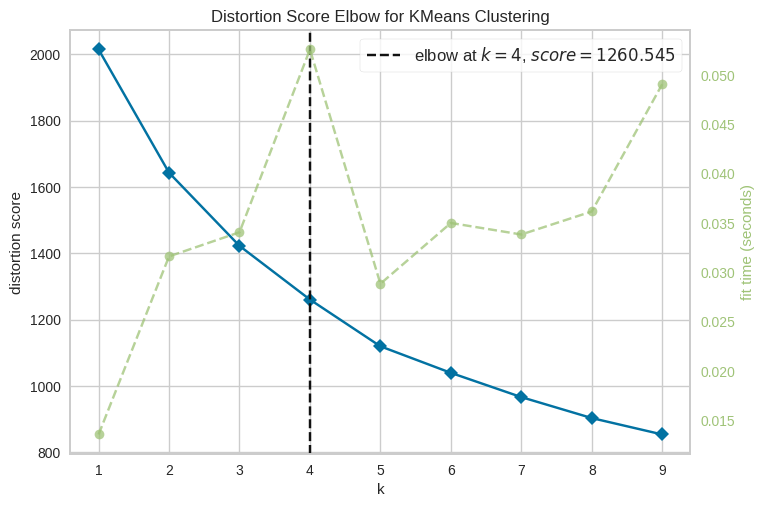

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [214]:
kmeans = KMeans(init='k-means++', n_init=5, max_iter=300, random_state=42)
visualizer = KElbowVisualizer(kmeans, k=(1,10))
visualizer.fit(X_processed)
visualizer.poof()

In [218]:
km = KMeans(n_clusters=4, init='k-means++', n_init=5, max_iter=300, random_state=42)
lab = km.fit_predict(X_processed)
print(silhouette_score(X_processed, lab))
print(calinski_harabasz_score(X_processed, lab))

0.17263292570828118
79.6024715069354


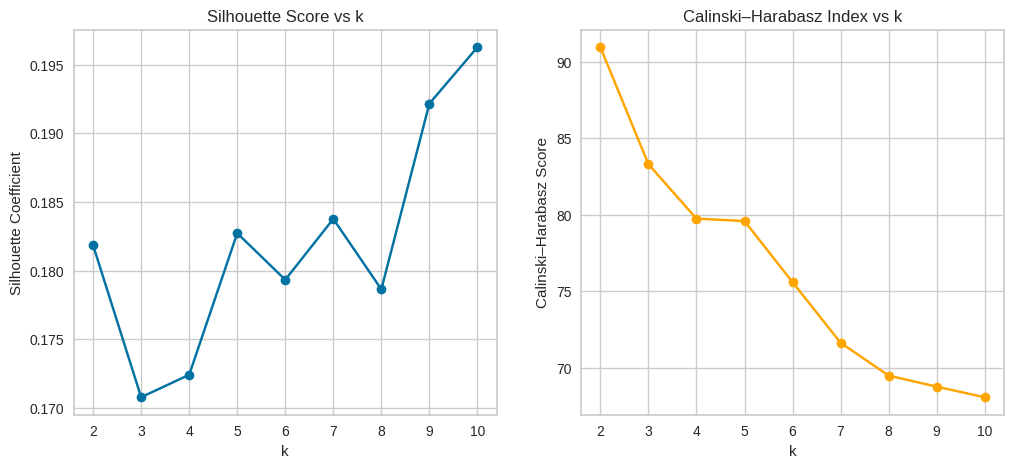

Silhouette Score score:  0.17240838212507953
Calinski–Harabasz score:  79.74104348160714


In [216]:
sil_scores = []
ch_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    lab = km.fit_predict(X_processed)
    sil_scores.append(silhouette_score(X_processed, lab))
    ch_scores.append(calinski_harabasz_score(X_processed, lab))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Coefficient")

plt.subplot(1, 2, 2)
plt.plot(K_range, ch_scores, marker='o', color='orange')
plt.title("Calinski–Harabasz Index vs k")
plt.xlabel("k")
plt.ylabel("Calinski–Harabasz Score")

plt.show()

print("Silhouette Score score: ", sil_scores[2])
print("Calinski–Harabasz score: ", ch_scores[2])

# DBSCAN

In [274]:
clusterer = DBSCAN(eps=1.283, min_samples=5)
y_pred = clusterer.fit_predict(X_processed)

sil = silhouette_score(X_processed, y_pred)
ch = calinski_harabasz_score(X_processed, y_pred)

print("Silhouette Coefficient:", sil) # > 0.5
print("Calinski–Harabasz Index:", ch) # > 150

Silhouette Coefficient: 0.1835239725886542
Calinski–Harabasz Index: 20.948837011882265


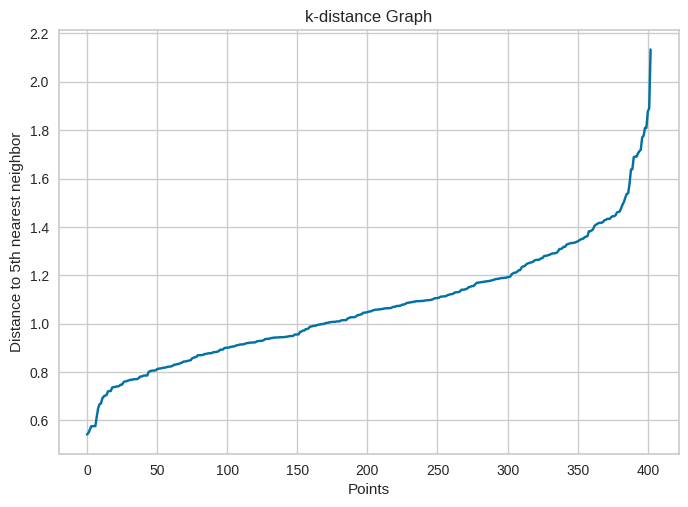

In [203]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_processed)
distances, indices = neighbors_fit.kneighbors(X_processed)

distances = np.sort(distances[:, 4])
plt.plot(distances)
plt.title("k-distance Graph")
plt.xlabel("Points")
plt.ylabel("Distance to 5th nearest neighbor")
plt.show()
